In [2]:
# load the necessary functions
# for (fnm in list.files("/home/jovyan/shared_materials/rwwa", full.names = T)) source(fnm)

# import R libraries from WWA
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector

ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

# print(ro.r('.libPaths()'))

R callback write-console: also installing the dependencies ‘systemfonts’, ‘textshaping’, ‘ragg’, ‘pkgdown’

  
R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In install.packages("devtools", repos = "https://cloud.r-project.org",  :  
R callback write-console: 
   
R callback write-console:  installation of package ‘systemfonts’ had non-zero exit status
  
R callback write-console: 2:   
R callback write-console: In install.packages("devtools", repos = "https://cloud.r-project.org",  :  
R callback write-console: 
   
R callback write-console:  installation of package ‘textshaping’ had non-zero exit status
  
R callback write-console: 3:   
R callback write-console: In install.packages("devtools", repos = "https://cloud.r-project.org",  :  
R callback write-console: 
   
R callback write-console:  installation of package ‘ragg’ had non-zero exit status
  
R callback write-console: 4:   
R

RRuntimeError: Error in loadNamespace(x) : there is no package called ‘devtools’


# Synthesise results from observations and climate models

In [ ]:
%%R
# load the observational results
df_obs <- read.csv("res-obs.csv", row.names = "X")

In [ ]:
%%R
# load the climate model results
df_models <- read.csv("res-models_cordex.csv", row.names = "X")

In [ ]:
%%R
# list the models to INCLUDE in the analysis (use the results spreadsheet to populate the list)
include <- c("CCCma-CanESM2_CLMcom-CCLM4-8-17",
             "CNRM-CERFACS-CNRM-CM5_CNRM-ALADIN63",
             "MOHC-HadGEM2-ES_KNMI-RACMO22E",
             "MOHC-HadGEM2-ES_MOHC-HadREM3-GA7-05",
             "MPI-M-MPI-ESM-LR_DMI-HIRHAM5")

# filter to retain only the models that passed model evaluation
df_models <- df_models[rownames(df_models) %in% include,]

In [ ]:
%%R
# if looking at temperature data / 'shift' fit, use "abs"; if looking at precipitation / 'fixeddisp', use "rel"
synthesis_type <- "abs"

In [ ]:
%%R
# change in intensity from past-present
synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
                           models_in = df_models[,grepl("attr_dI", colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), 
                           synth_type = "PR")

# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

Warning message in max(u_n[is.finite(u_n)]):
“no non-missing arguments to max; returning -Inf”
Warning message in log(est_n):
“NaNs produced”
Warning message in log(est_n):
“NaNs produced”
Warning message in FUN(X[[i]], ...):
“NaNs produced”


In [ ]:
%%R
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_dI", colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from present-future
synth_PR_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))], 
                           synth_type = "PR")

In [ ]:
%%R
# save all the synthesised results
write.csv(synth_dI_attr$df, "synth_dI_attr.csv")
write.csv(synth_PR_attr$df, "synth_PR_attr.csv")
write.csv(synth_dI_proj$df, "synth_dI_proj.csv")
write.csv(synth_PR_proj$df, "synth_PR_proj.csv")

## Synthesis figures

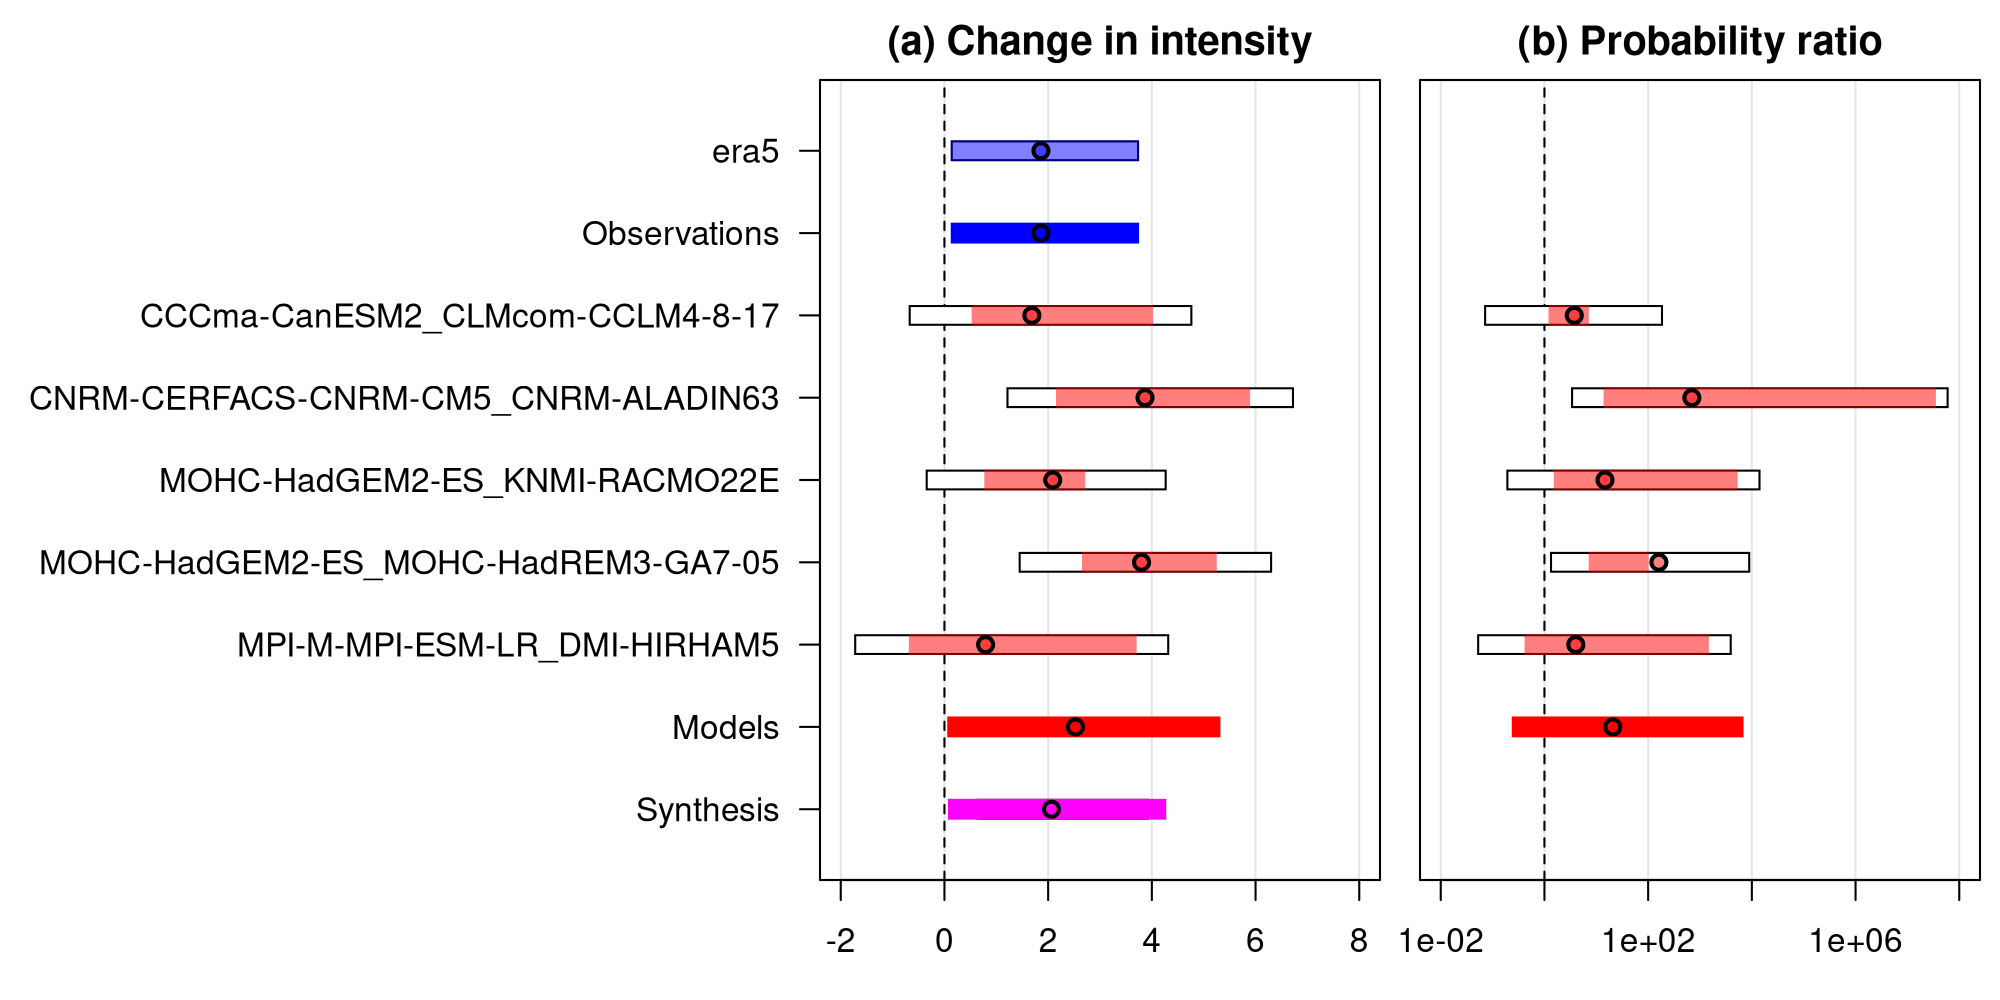

In [ ]:
%%R
# put two figures next to each other
prep_window(c(1,2),
            h = 5,                    # height of the figure (ins)
            w = 5,                    # width of each panel (ins)
            oma = c(0,20,0,0),        # increase second number until model names fit in margin
            mar = c(3,0.5,2,0.5))     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))

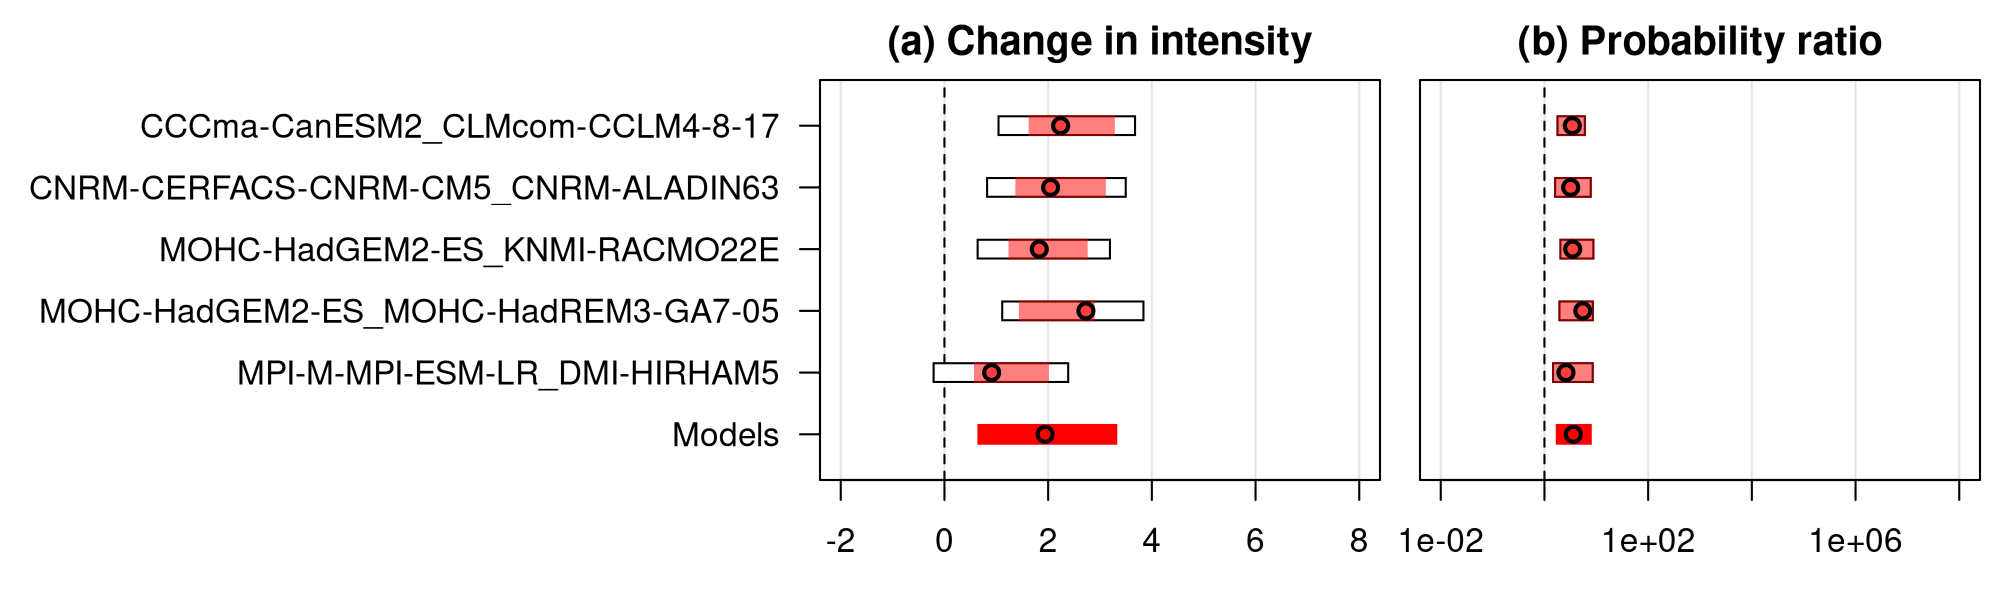

In [ ]:
%%R
prep_window(c(1,2),
            h = 3,                    # height of the figure (ins)
            w = 5,                    # width of each panel (ins)
            oma = c(0,20,0,0),        # increase second number until model names fit in margin
            mar = c(3,0.5,2,0.5))     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))

## Produce figures of the synthesis

In [ ]:
%%R
png("synth-fig_attr.png", height = 360, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

pdf 
  2

In [ ]:
%%R
png("synth-fig_proj.png", height = 240, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

pdf 
  2